# Wigner function to Density matrix

In [42]:
import numpy as np
from scipy.special import genlaguerre, factorial
import matplotlib.pyplot as plt
from WignerDensity import rho_to_Wigner, Wigner_to_rho

[[0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]]


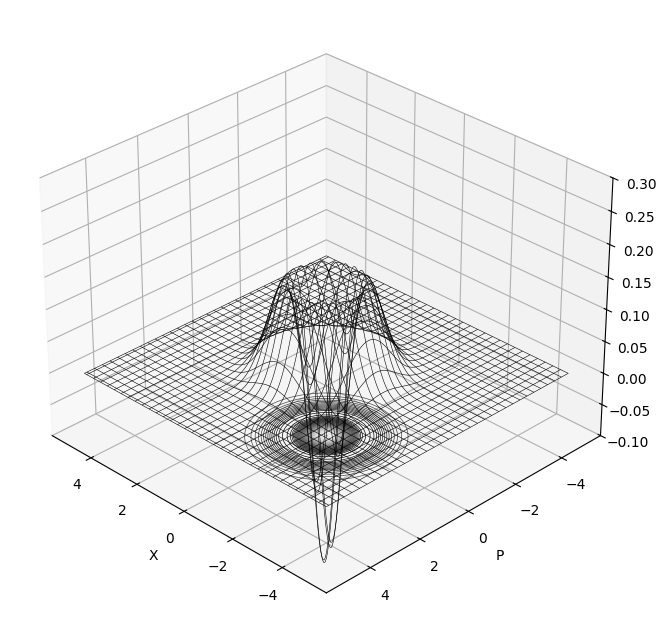

[[ 0.+0.j  0.-0.j  0.+0.j -0.+0.j -0.-0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.-0.j  0.-0.j]
 [ 0.-0.j  0.-0.j  0.+0.j -0.-0.j  0.-0.j]
 [-0.-0.j  0.+0.j -0.+0.j  0.+0.j  0.+0.j]
 [-0.+0.j  0.+0.j  0.+0.j  0.-0.j -0.+0.j]]


In [43]:
dim = 5
rho = np.zeros((dim, dim), dtype=complex)
rho[1, 1] = 1.0  # |1><1|
print(rho)

xgrid = np.linspace(-5, 5, 201)
pgrid = np.linspace(-5, 5, 201)

W = rho_to_Wigner(rho, xgrid, pgrid)

# Plotting Wigner function in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
X, P = np.meshgrid(xgrid, pgrid, indexing='ij')
ax.plot_wireframe(X, P, np.real(W), rstride=6, cstride=6, color='black', linewidth=0.4)
ax.contour(X, P, np.real(W), zdir='z', offset=-0.1, levels=50, cmap='binary', linewidths=0.5)
ax.set_xlabel("X")
ax.set_ylabel("P")
ax.set_zlim(-0.1, 0.3)
ax.view_init(elev=30, azim=135)
plt.show()

# Recover rho from Wigner
rho_rec = Wigner_to_rho(W, xgrid, pgrid, dim)

print(np.round(rho_rec, 3))